In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df_ipma = pd.read_excel("PGIL_IPMA_METEO_OBS_SetOut2023.xlsx", engine='openpyxl')

In [2]:

display(df_ipma.head(5))


,entity_id,estacion,fecha,humidade,iddireccvento,intensidadevento,intensidadeventokm,precacumulada,pressao,radiacao,temperatura
0,ipma.estacionesMetereologicas.1200535,1200535,2023-09-01 12:00:00,46.0,1.0,2.9,10.4,0.0,1017.1,2476.7,26.1
1,ipma.estacionesMetereologicas.1210762,1210762,2023-09-01 15:00:00,47.0,8.0,4.3,15.5,0.0,-99.0,1529.2,26.4
2,ipma.estacionesMetereologicas.1200535,1200535,2023-09-02 10:00:00,62.0,9.0,5.4,19.4,0.0,1012.8,1560.5,20.9
3,ipma.estacionesMetereologicas.7240919,7240919,2023-09-03 21:00:00,93.0,6.0,0.7,2.5,0.0,1009.9,-99.0,17.4
4,ipma.estacionesMetereologicas.1210762,1210762,2023-09-04 13:00:00,85.0,5.0,5.0,18.0,0.2,-99.0,959.2,20.8


In [3]:

print("Estações disponíveis:", df_ipma['estacion'].unique())

print("De", df_ipma['fecha'].min(), "até", df_ipma['fecha'].max())

display(df_ipma.describe())




Estações disponíveis: [1200535 1210762 7240919 1200579]
De 2023-09-01 00:00:00 até 2023-10-31 22:00:00


,estacion,fecha,humidade,iddireccvento,intensidadevento,intensidadeventokm,precacumulada,pressao,radiacao,temperatura
count,5.827000e+03,5827,5732.000000,5732.000000,5732.000000,5732.000000,5732.000000,5732.000000,5732.000000,5732.000000
mean,2.713458e+06,2023-10-01 10:31:02.708083200,71.773552,5.225052,-1.862090,4.433200,-6.163451,716.896075,409.791678,18.115998
min,1.200535e+06,2023-09-01 00:00:00,-99.000000,0.000000,-99.000000,-99.000000,-99.000000,-99.000000,-99.000000,-99.000000
25%,1.200557e+06,2023-09-16 04:00:00,60.000000,3.000000,1.200000,4.300000,0.000000,-99.000000,-99.000000,18.100000
50%,1.210762e+06,2023-10-01 11:00:00,78.000000,6.000000,2.100000,7.600000,0.000000,1013.900000,0.000000,19.900000
75%,4.225840e+06,2023-10-16 16:00:00,92.000000,7.000000,3.300000,11.900000,0.000000,1018.700000,481.450000,22.700000
max,7.240919e+06,2023-10-31 22:00:00,100.000000,9.000000,10.400000,37.400000,21.600000,1024.900000,3156.100000,35.700000
std,2.614457e+06,NaN,31.903083,2.525586,20.720549,22.738499,24.192323,493.488841,815.687176,17.853745


In [4]:
unique_counts = df_ipma.nunique()

print(unique_counts)

entity_id                4
estacion                 4
fecha                 1427
humidade                84
iddireccvento           10
intensidadevento       100
intensidadeventokm     100
precacumulada           70
pressao                287
radiacao              2018
temperatura            228
dtype: int64


In [ ]:
# Verificar se há valores -99 (valores inválidos em algumas colunas como pressão ou radiação)
print((df_ipma == -99.0).sum())

entity_id                0
estacion                 0
fecha                    0
humidade               124
iddireccvento            0
intensidadevento       248
intensidadeventokm     248
precacumulada          364
pressao               1535
radiacao              1581
temperatura            124
dtype: int64


In [6]:
df_ipma.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5827 entries, 0 to 5826
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   entity_id           5827 non-null   object        
 1   estacion            5827 non-null   int64         
 2   fecha               5827 non-null   datetime64[ns]
 3   humidade            5732 non-null   float64       
 4   iddireccvento       5732 non-null   float64       
 5   intensidadevento    5732 non-null   float64       
 6   intensidadeventokm  5732 non-null   float64       
 7   precacumulada       5732 non-null   float64       
 8   pressao             5732 non-null   float64       
 9   radiacao            5732 non-null   float64       
 10  temperatura         5732 non-null   float64       
dtypes: datetime64[ns](1), float64(8), int64(1), object(1)
memory usage: 500.9+ KB


In [7]:
df_ipma.count()



entity_id             5827
estacion              5827
fecha                 5827
humidade              5732
iddireccvento         5732
intensidadevento      5732
intensidadeventokm    5732
precacumulada         5732
pressao               5732
radiacao              5732
temperatura           5732
dtype: int64

In [8]:
df_ipma.isnull().sum()

entity_id              0
estacion               0
fecha                  0
humidade              95
iddireccvento         95
intensidadevento      95
intensidadeventokm    95
precacumulada         95
pressao               95
radiacao              95
temperatura           95
dtype: int64

In [9]:

erros_medicao = df_ipma[df_ipma['precacumulada'] == -99]


print(f"\nTotal de registos com erro de medição: {len(erros_medicao)}")



Total de registos com erro de medição: 364


In [10]:
df_ipma = df_ipma.drop(columns=['entity_id'])

In [11]:
df_ipma.head(5) 

,estacion,fecha,humidade,iddireccvento,intensidadevento,intensidadeventokm,precacumulada,pressao,radiacao,temperatura
0,1200535,2023-09-01 12:00:00,46.0,1.0,2.9,10.4,0.0,1017.1,2476.7,26.1
1,1210762,2023-09-01 15:00:00,47.0,8.0,4.3,15.5,0.0,-99.0,1529.2,26.4
2,1200535,2023-09-02 10:00:00,62.0,9.0,5.4,19.4,0.0,1012.8,1560.5,20.9
3,7240919,2023-09-03 21:00:00,93.0,6.0,0.7,2.5,0.0,1009.9,-99.0,17.4
4,1210762,2023-09-04 13:00:00,85.0,5.0,5.0,18.0,0.2,-99.0,959.2,20.8


EXPLORAÇÃO DOS DADOS

Top 10 dias com maior precipitação acumulada (todas as estações, valores válidos):
          data  precacumulada
48  2023-10-19          112.8
46  2023-10-17           97.8
53  2023-10-24           89.6
8   2023-09-09           89.5
58  2023-10-29           49.4
57  2023-10-28           43.9
3   2023-09-04           40.9
15  2023-09-16           28.0
52  2023-10-23           14.9
16  2023-09-17           14.5


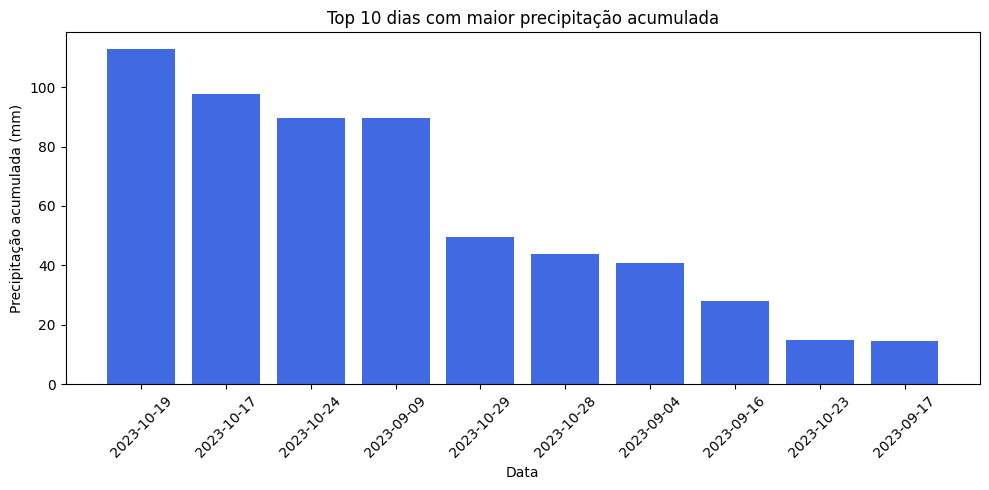

In [12]:
df_prec_valid = df_ipma[df_ipma['precacumulada'] >= 0].copy()


df_prec_valid['data'] = df_prec_valid['fecha'].dt.date

prec_por_dia = df_prec_valid.groupby('data')['precacumulada'].sum().reset_index()


top_dias_prec = prec_por_dia.sort_values(by='precacumulada', ascending=False).head(10)


print("Top 10 dias com maior precipitação acumulada (todas as estações, valores válidos):")
print(top_dias_prec)

plt.figure(figsize=(10, 5))
plt.bar(top_dias_prec['data'].astype(str), top_dias_prec['precacumulada'], color='royalblue')
plt.xlabel('Data')
plt.ylabel('Precipitação acumulada (mm)')
plt.title('Top 10 dias com maior precipitação acumulada')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [13]:
top_prec_horas = df_prec_valid.sort_values(by='precacumulada', ascending=False)
top_prec_horas = top_prec_horas[['fecha', 'estacion', 'precacumulada']].head(10)


print(top_prec_horas)


                   fecha  estacion  precacumulada
5561 2023-10-19 12:00:00   1200579           21.6
5560 2023-10-19 12:00:00   1210762           20.2
3151 2023-09-09 05:00:00   1210762           19.8
2441 2023-10-19 12:00:00   1200535           18.6
126  2023-09-09 08:00:00   1200579           13.2
3263 2023-10-17 03:00:00   1210762           12.8
1686 2023-09-09 05:00:00   1200579           12.8
2435 2023-10-17 12:00:00   1200535           12.7
1857 2023-10-19 12:00:00   7240919           12.5
533  2023-10-17 12:00:00   1210762           10.9


In [14]:

prec_por_hora = df_prec_valid.groupby('fecha')['precacumulada'].sum().reset_index()
hora_critica = prec_por_hora.sort_values(by='precacumulada', ascending=False).head(1)

print("Hora mais crítica a nível de precipitação acumulada (soma de todas as estações):")
print(hora_critica)


Hora mais crítica a nível de precipitação acumulada (soma de todas as estações):
                   fecha  precacumulada
1138 2023-10-19 12:00:00           72.9


Hora com maior média de precipitação: 12.0h → 0.52 mm
Hora com menor média de precipitação: 23.0h → 0.02 mm


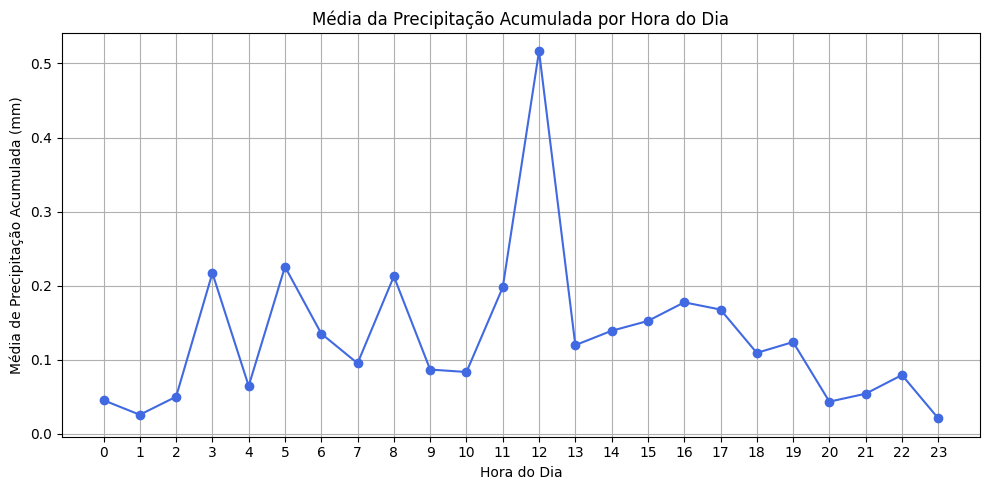

In [15]:
df_prec_valid['hora'] = df_prec_valid['fecha'].dt.hour
media_prec_por_hora = df_prec_valid.groupby('hora')['precacumulada'].mean().reset_index()
media_prec_por_hora = media_prec_por_hora.sort_values('hora')

#horas com maior e menor média de precipitação acumulada
hora_max = media_prec_por_hora.loc[media_prec_por_hora['precacumulada'].idxmax()]
hora_min = media_prec_por_hora.loc[media_prec_por_hora['precacumulada'].idxmin()]

print(f"Hora com maior média de precipitação: {hora_max['hora']}h → {hora_max['precacumulada']:.2f} mm")
print(f"Hora com menor média de precipitação: {hora_min['hora']}h → {hora_min['precacumulada']:.2f} mm")


plt.figure(figsize=(10, 5))
plt.plot(media_prec_por_hora['hora'], media_prec_por_hora['precacumulada'], marker='o', color='royalblue')
plt.title('Média da Precipitação Acumulada por Hora do Dia')
plt.xlabel('Hora do Dia')
plt.ylabel('Média de Precipitação Acumulada (mm)')
plt.xticks(range(0, 24))
plt.grid(True)
plt.tight_layout()
plt.show()

In [16]:
prec_por_estacao = df_prec_valid.groupby('estacion')['precacumulada'].sum().reset_index()

prec_por_estacao = prec_por_estacao.sort_values(by='precacumulada', ascending=False)


print(prec_por_estacao)


   estacion  precacumulada
2   1210762          209.5
0   1200535          193.7
1   1200579          190.4
3   7240919          113.5


In [17]:
media_prec_por_estacao = df_prec_valid.groupby('estacion')['precacumulada'].mean().reset_index()
media_prec_por_estacao = media_prec_por_estacao.sort_values(by='precacumulada', ascending=False)
print(media_prec_por_estacao)


   estacion  precacumulada
2   1210762       0.154613
0   1200535       0.145639
1   1200579       0.138473
3   7240919       0.086774


In [18]:

#apenas os dias com precipitação > 1mm
dias_com_precipitacao = prec_por_dia[prec_por_dia['precacumulada'] > 1]


print("Dias com ocorrência de precipitação (total > 1 mm):")
print(dias_com_precipitacao)


Dias com ocorrência de precipitação (total > 1 mm):
          data  precacumulada
2   2023-09-03           13.3
3   2023-09-04           40.9
4   2023-09-05            3.0
7   2023-09-08            9.7
8   2023-09-09           89.5
9   2023-09-10           14.1
10  2023-09-11            1.7
15  2023-09-16           28.0
16  2023-09-17           14.5
20  2023-09-21            8.8
42  2023-10-13            2.2
43  2023-10-14            1.2
44  2023-10-15            6.2
45  2023-10-16            1.9
46  2023-10-17           97.8
47  2023-10-18            1.1
48  2023-10-19          112.8
49  2023-10-20            6.9
50  2023-10-21            5.1
51  2023-10-22           14.1
52  2023-10-23           14.9
53  2023-10-24           89.6
54  2023-10-25            8.6
55  2023-10-26            6.8
56  2023-10-27           13.1
57  2023-10-28           43.9
58  2023-10-29           49.4
59  2023-10-30            5.2
60  2023-10-31            1.2


In [19]:
df_prec_valid = df_ipma[df_ipma['precacumulada'] >= 0].copy()
prec_por_dia=df_prec_valid.groupby('fecha')['precacumulada'].sum().reset_index() 
dias_chuva_signif = prec_por_dia[prec_por_dia['precacumulada'] >= 1]
print(f"Dias com precipitação ≥ 1 mm: {dias_chuva_signif.shape[0]}")


Dias com precipitação ≥ 1 mm: 114


In [20]:
horas_com_chuva = df_prec_valid[df_prec_valid['precacumulada'] > 0]
num_horas_com_chuva = horas_com_chuva.shape[0]

print(f"Número de horas com ocorrência de precipitação: {num_horas_com_chuva}")


Número de horas com ocorrência de precipitação: 670


In [21]:
valores_direcc_vento = df_ipma['iddireccvento'].unique()
print(sorted(valores_direcc_vento))


[0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, nan]


In [22]:
# casos em que a direção do vento é 0.0 ou NaN
filtros = (df_ipma['iddireccvento'] == 0.0) | (df_ipma['iddireccvento'].isna())
casos_vento_invalido = df_ipma[filtros]
display(casos_vento_invalido.head(10))


,estacion,fecha,humidade,iddireccvento,intensidadevento,intensidadeventokm,precacumulada,pressao,radiacao,temperatura
7,1210762,2023-09-05 09:00:00,90.0,0.0,-99.0,-99.0,-99.0,-99.0,-99.0,21.2
56,1200579,2023-09-01 23:00:00,75.0,0.0,-99.0,-99.0,-99.0,1015.6,-99.0,19.9
116,1200579,2023-09-07 23:00:00,88.0,0.0,-99.0,-99.0,-99.0,1016.0,-99.0,21.1
183,1200579,2023-09-14 23:00:00,62.0,0.0,-99.0,-99.0,-99.0,1012.5,-99.0,22.2
189,1200579,2023-09-15 23:00:00,80.0,0.0,-99.0,-99.0,-99.0,1010.3,-99.0,20.2
195,7240919,2023-09-15 14:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
213,1200579,2023-09-17 09:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
268,7240919,2023-09-23 20:00:00,68.0,0.0,-99.0,-99.0,-99.0,1019.3,-99.0,20.7
326,1200579,2023-09-27 19:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
327,7240919,2023-09-27 19:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:

df_vento_valido = df_ipma[(df_ipma['intensidadeventokm'].notna()) & (df_ipma['intensidadeventokm'] != -99)]


velocidade_media_vento = df_vento_valido['intensidadeventokm'].mean()

print(f"Velocidade média global do vento (km/h): {velocidade_media_vento:.2f}")


Velocidade média global do vento (km/h): 9.11


In [24]:
top_vento = df_vento_valido.sort_values(by='intensidadeventokm', ascending=False).head(20)
display(top_vento[['fecha', 'estacion', 'intensidadeventokm']])


,fecha,estacion,intensidadeventokm
2440,2023-10-19 10:00:00,1200579,37.4
1522,2023-10-19 09:00:00,1200535,37.4
4669,2023-10-19 09:00:00,1200579,37.4
5099,2023-10-17 03:00:00,1200535,36.7
2529,2023-10-17 02:00:00,1200535,36.4
1562,2023-10-26 11:00:00,1200579,36.4
3892,2023-10-19 08:00:00,1200535,35.6
1858,2023-10-19 11:00:00,1200535,35.6
1859,2023-10-19 10:00:00,1200535,34.9
556,2023-10-19 00:00:00,1200579,33.8


In [25]:
df_vento_valido['data'] = df_vento_valido['fecha'].dt.date

media_vento_por_dia = df_vento_valido.groupby('data')['intensidadeventokm'].mean().reset_index()

top5_dias_vento = media_vento_por_dia.sort_values(by='intensidadeventokm', ascending=False).head(5)

print("Top 5 dias com maior média de intensidade de vento:")
print(top5_dias_vento)


Top 5 dias com maior média de intensidade de vento:
          data  intensidadeventokm
46  2023-10-17           20.831461
48  2023-10-19           20.735294
47  2023-10-18           15.390426
55  2023-10-26           15.068750
16  2023-09-17           14.800000


C:\Users\simao\AppData\Local\Temp\ipykernel_17384\2077936419.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_vento_valido['data'] = df_vento_valido['fecha'].dt.date


In [26]:
media_vento_por_estacao = df_vento_valido.groupby('estacion')['intensidadeventokm'].mean().reset_index()


media_vento_por_estacao = media_vento_por_estacao.sort_values(by='intensidadeventokm', ascending=False)


print("Intensidade média de vento por estação:")
print(media_vento_por_estacao)


Intensidade média de vento por estação:
   estacion  intensidadeventokm
1   1200579           11.628488
0   1200535           10.590781
3   7240919            7.144757
2   1210762            6.936761


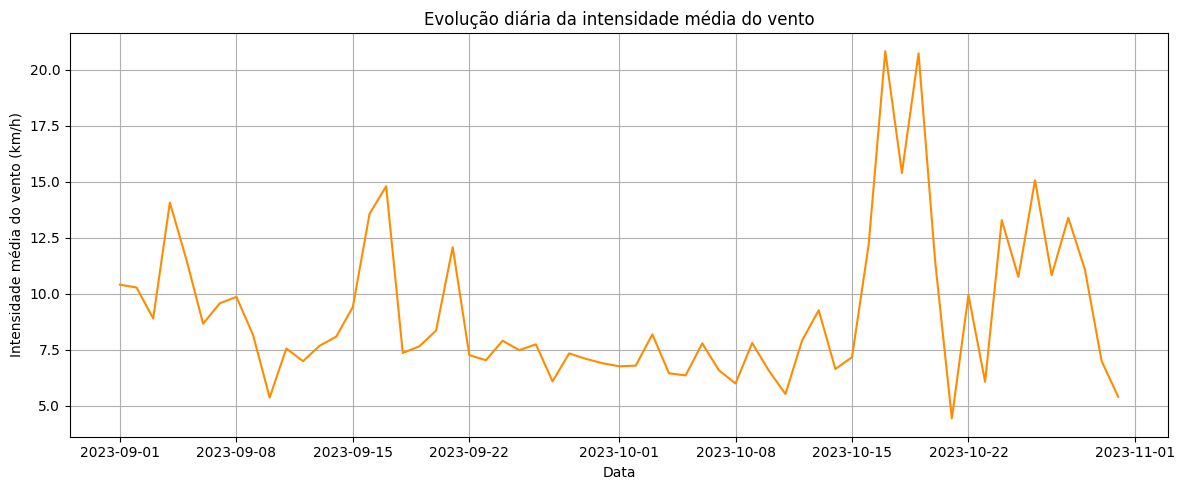

In [27]:
vento_por_dia = df_vento_valido.groupby('data')['intensidadeventokm'].mean().reset_index()


plt.figure(figsize=(12, 5))
plt.plot(vento_por_dia['data'], vento_por_dia['intensidadeventokm'], color='darkorange')
plt.xlabel('Data')
plt.ylabel('Intensidade média do vento (km/h)')
plt.title('Evolução diária da intensidade média do vento')
plt.grid(True)
plt.tight_layout()
plt.show()


In [28]:

df_temperatura_val = df_ipma[(df_ipma['temperatura'] != -99) & (df_ipma['temperatura'].notna())]

In [29]:

media_temp = df_temperatura_val['temperatura'].mean()


max_temp = df_temperatura_val['temperatura'].max()
min_temp = df_temperatura_val['temperatura'].min()

momento_max = df_temperatura_val[df_temperatura_val['temperatura'] == max_temp][['fecha', 'estacion']]
momento_min = df_temperatura_val[df_temperatura_val['temperatura'] == min_temp][['fecha', 'estacion']]

print(f"Temperatura média global: {media_temp:.2f}°C")
print(f"Temperatura máxima: {max_temp}°C em:\n{momento_max}")
print(f"Temperatura mínima: {min_temp}°C em:\n{momento_min}")


Temperatura média global: 20.71°C
Temperatura máxima: 35.7°C em:
                   fecha  estacion
4100 2023-09-30 16:00:00   7240919
Temperatura mínima: 12.0°C em:
                   fecha  estacion
614  2023-10-23 23:00:00   1210762
5698 2023-10-30 06:00:00   1210762


In [30]:
df_temperatura_val['data'] = pd.to_datetime(df_temperatura_val['fecha']).dt.date

media_diaria = df_temperatura_val.groupby('data')['temperatura'].mean().reset_index()

dia_mais_quente = media_diaria.loc[media_diaria['temperatura'].idxmax()]
dia_mais_frio = media_diaria.loc[media_diaria['temperatura'].idxmin()]

print(f"Dia mais quente: {dia_mais_quente['data']} com {dia_mais_quente['temperatura']:.2f}°C")
print(f"Dia mais frio: {dia_mais_frio['data']} com {dia_mais_frio['temperatura']:.2f}°C")


Dia mais quente: 2023-09-30 com 26.31°C
Dia mais frio: 2023-10-22 com 15.26°C


C:\Users\simao\AppData\Local\Temp\ipykernel_17384\2969974471.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_temperatura_val['data'] = pd.to_datetime(df_temperatura_val['fecha']).dt.date


C:\Users\simao\AppData\Local\Temp\ipykernel_17384\955590807.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_temperatura_val['hora'] = pd.to_datetime(df_temperatura_val['fecha']).dt.hour


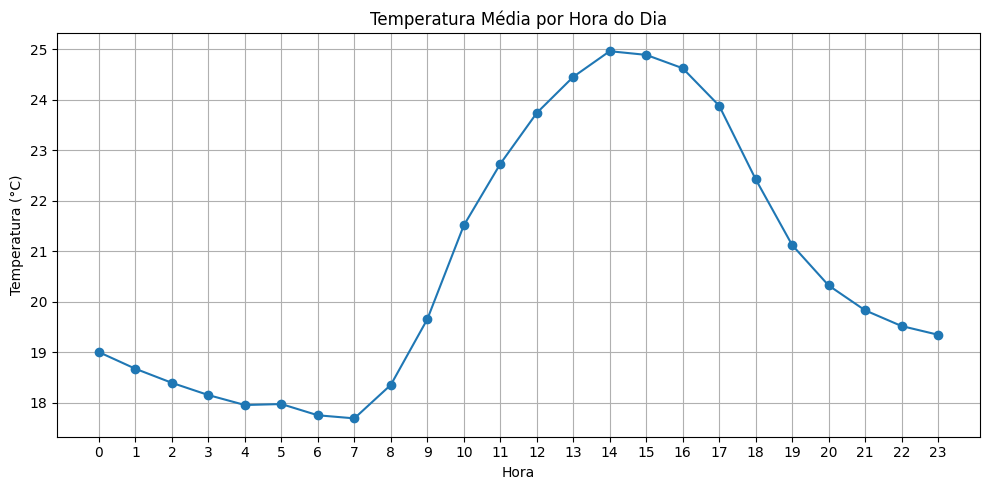

In [31]:
df_temperatura_val['hora'] = pd.to_datetime(df_temperatura_val['fecha']).dt.hour

media_por_hora = df_temperatura_val.groupby('hora')['temperatura'].mean().reset_index()


plt.figure(figsize=(10, 5))
plt.plot(media_por_hora['hora'], media_por_hora['temperatura'], marker='o')
plt.title('Temperatura Média por Hora do Dia')
plt.xlabel('Hora')
plt.ylabel('Temperatura (°C)')
plt.xticks(range(0, 24))
plt.grid(True)
plt.tight_layout()
plt.show()


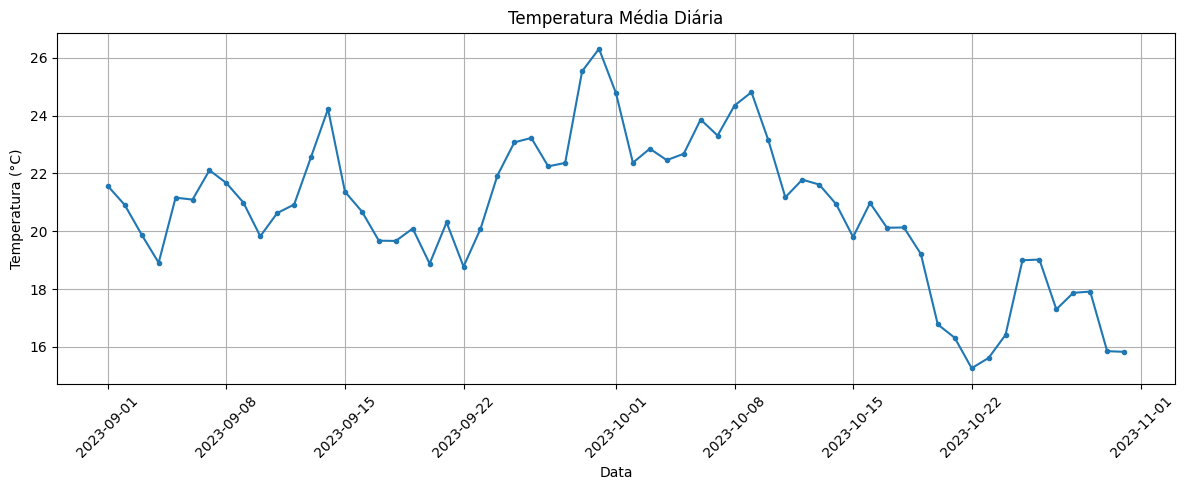

In [32]:
plt.figure(figsize=(12, 5))
plt.plot(media_diaria['data'], media_diaria['temperatura'], marker='.')
plt.title('Temperatura Média Diária')
plt.xlabel('Data')
plt.ylabel('Temperatura (°C)')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:

media_por_estacao = df_temperatura_val.groupby('estacion')['temperatura'].mean().reset_index()

media_por_estacao = media_por_estacao.sort_values(by='temperatura', ascending=False)

print(media_por_estacao)


   estacion  temperatura
3   7240919    21.020784
0   1200535    20.882282
1   1200579    20.669344
2   1210762    20.257597


In [ ]:
df_ipma.replace(-99.0, np.nan, inplace=True)


print("Contagem de nulos após unificação:")
print(df_ipma.isnull().sum())

Contagem de nulos após unificação:
estacion                 0
fecha                    0
humidade               219
iddireccvento           95
intensidadevento       343
intensidadeventokm     343
precacumulada          459
pressao               1630
radiacao              1676
temperatura            219
dtype: int64


In [35]:
df_ipma_agregado = df_ipma.groupby('fecha').mean()
df_ipma_agregado = df_ipma_agregado.ffill().bfill()
df_ipma_agregado = df_ipma_agregado.round(2)
df_ipma_agregado = df_ipma_agregado.reset_index()

if 'estacion' in df_ipma_agregado.columns:
    df_ipma_agregado = df_ipma_agregado.drop(columns=['estacion'])


df_ipma = df_ipma_agregado.copy()
df_ipma.head(5)

,fecha,humidade,iddireccvento,intensidadevento,intensidadeventokm,precacumulada,pressao,radiacao,temperatura
0,2023-09-01 00:00:00,80.00,1.50,2.70,9.70,0.0,1017.90,0.0,18.97
1,2023-09-01 01:00:00,81.75,5.25,2.78,10.00,0.0,1017.83,0.0,18.62
2,2023-09-01 02:00:00,82.75,3.25,2.58,9.28,0.0,1017.53,0.0,18.48
3,2023-09-01 03:00:00,84.50,4.75,1.85,6.68,0.0,1017.23,0.0,18.08
4,2023-09-01 04:00:00,86.25,6.75,2.17,7.82,0.0,1016.80,0.0,17.73


In [36]:
df_ipma = df_ipma.set_index('fecha')
df_ipma = df_ipma.sort_index()

colunas_para_tratar = ['humidade', 'iddireccvento', 'intensidadevento', 'intensidadeventokm', 'pressao', 'temperatura', 'radiacao']


for coluna in colunas_para_tratar:
    df_ipma[coluna] = df_ipma[coluna].interpolate(method='time').bfill().ffill()

df_ipma[colunas_para_tratar] = df_ipma[colunas_para_tratar].fillna(df_ipma[colunas_para_tratar].mean())

media_horaria_geral = df_ipma['precacumulada'].mean()
df_ipma['precacumulada'].fillna(media_horaria_geral, inplace=True)
df_ipma.rename(columns={'precacumulada': 'precipitacao_horaria'}, inplace=True)

bins = [-0.1, 0.1, 2.5, 7.0, np.inf]
labels = ['Sem Chuva', 'Chuva Fraca', 'Chuva Moderada', 'Chuva Forte']
df_ipma['classe_chuva'] = pd.cut(df_ipma['precipitacao_horaria'], bins=bins, labels=labels, right=False)

df_ipma = df_ipma.reset_index()

print(df_ipma.isnull().sum())

fecha                   0
humidade                0
iddireccvento           0
intensidadevento        0
intensidadeventokm      0
precipitacao_horaria    0
pressao                 0
radiacao                0
temperatura             0
classe_chuva            0
dtype: int64


In [37]:
df_ipma.head(5)    

,fecha,humidade,iddireccvento,intensidadevento,intensidadeventokm,precipitacao_horaria,pressao,radiacao,temperatura,classe_chuva
0,2023-09-01 00:00:00,80.00,1.50,2.70,9.70,0.0,1017.90,0.0,18.97,Sem Chuva
1,2023-09-01 01:00:00,81.75,5.25,2.78,10.00,0.0,1017.83,0.0,18.62,Sem Chuva
2,2023-09-01 02:00:00,82.75,3.25,2.58,9.28,0.0,1017.53,0.0,18.48,Sem Chuva
3,2023-09-01 03:00:00,84.50,4.75,1.85,6.68,0.0,1017.23,0.0,18.08,Sem Chuva
4,2023-09-01 04:00:00,86.25,6.75,2.17,7.82,0.0,1016.80,0.0,17.73,Sem Chuva


In [38]:
chuva_muito_forte = df_ipma[df_ipma['classe_chuva'] == 'Chuva Forte']
display(chuva_muito_forte.head(5))

,fecha,humidade,iddireccvento,intensidadevento,intensidadeventokm,precipitacao_horaria,pressao,radiacao,temperatura,classe_chuva
194,2023-09-09 05:00:00,98.75,5.25,1.55,5.57,11.20,1013.23,0.00,18.73,Chuva Forte
1082,2023-10-17 03:00:00,97.25,6.00,7.28,26.20,9.30,1000.37,3.07,20.38,Chuva Forte
1091,2023-10-17 12:00:00,98.75,4.50,5.97,21.47,9.63,1001.63,235.37,19.62,Chuva Forte
1139,2023-10-19 12:00:00,99.00,7.00,6.90,24.88,18.23,994.27,48.93,18.75,Chuva Forte


In [39]:
df_ipma_final = df_ipma[['fecha', 'classe_chuva']] 

In [40]:
chuva_muito_forte = df_ipma_final[df_ipma_final['classe_chuva'] == 'Chuva Forte']
display(chuva_muito_forte)

,fecha,classe_chuva
194,2023-09-09 05:00:00,Chuva Forte
1082,2023-10-17 03:00:00,Chuva Forte
1091,2023-10-17 12:00:00,Chuva Forte
1139,2023-10-19 12:00:00,Chuva Forte


In [41]:
print(df_ipma_final.isnull().sum())

fecha           0
classe_chuva    0
dtype: int64


In [42]:
df_ipma_final.head(10)

,fecha,classe_chuva
0,2023-09-01 00:00:00,Sem Chuva
1,2023-09-01 01:00:00,Sem Chuva
2,2023-09-01 02:00:00,Sem Chuva
3,2023-09-01 03:00:00,Sem Chuva
4,2023-09-01 04:00:00,Sem Chuva
5,2023-09-01 05:00:00,Sem Chuva
6,2023-09-01 06:00:00,Sem Chuva
7,2023-09-01 07:00:00,Sem Chuva
8,2023-09-01 08:00:00,Sem Chuva
9,2023-09-01 09:00:00,Sem Chuva


In [43]:
df_ipma_final.to_csv('ipma_dados_preparados.csv', index=False)
